# Model fitting with oimBinaryOrbit 

Here we present advanced features of the new oimBinaryOrbit component.The more
basic features are detailed in exampleOimBinaryOrbit.ipynb.

For this example, we are using some data from [Meilland et al. (2011)](https://ui.adsabs.harvard.edu/abs/2011A%26A...532A..80M/abstract) paper:
    
    The binary Be star δ Scorpii at high spectral and spatial resolution.
       I. Disk geometry and kinematics before the 2011 periastron 
       
Our dataset consist in :
    
- **delsco_rv.dat** : RV around the 2001 periastron from [Miroshnichenko et al. (2001)](https://ui.adsabs.harvard.edu/abs/2001A%26A...377..485M/abstract)
- **delsco_position.dat** : separation measurtement (in mas) from litterature:
    - 4th Catalog of Interferometric Measurements of Binary Star [Hartkopf (2001)](https://ui.adsabs.harvard.edu/abs/2001AJ....122.3480H/abstract)
    - from [Tycner et al. (2011)](https://ui.adsabs.harvard.edu/abs/2011ApJ...729L...5T/abstract) derived  from NPOI data 
    - [Meilland et al. (2011)](https://ui.adsabs.harvard.edu/abs/2011A%26A...532A..80M/abstract) derived from AMBER data     
- 2 AMBER oifits files from Meilland et al. 2011 
    - **DelSco_K_2010-04-15T07h12_MR.fits**
    - **DelSco_K_2010-04-15T07h55_MR.fits**
    
In this example we show how to setup priors on the binary separation and radial
velocity and use them to perform fit with and without interferometric data.


Let's start with some imports

In [3]:
from pathlib import Path
import os
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from astropy.io import ascii
from astropy.time import Time
import oimodeler as oim

plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True


path = Path(os.getcwd()).parents[2] # oimodeler package root path

### Loading and ploting separation and radial-velocity data
 
Here we load our collected separation and RV data

In [6]:
fname_pos= path / "data" / "NonInterferometricData" /  "delsco_position.dat"
data = ascii.read(fname_pos)
mjd = np.array(data["mjd"]) # modified julian day
x = np.array(data["x"]) # in mas
y = np.array(data["y"]) # in mas 
err_x = np.array(data["err_x"]) # in mas
err_y = np.array(data["err_y"]) # in mas
source = np.array(data["source"]) # 0 = Hartkopf, 1 = Tycner, 2 = Meilland

fname_rv= path / "data" / "NonInterferometricData" / "delsco_rv.dat"
data_rv=ascii.read(fname_rv)
mjdRv = Time(data_rv["yr"],format="byear").mjd #time converted in MJD as it is the standard time unit in oimodeler
rv  =   np.array(data_rv["rv"]) # in km/s

We setup a binary model with the orbital parameters as determined in [Meilland et al. (2011)](https://ui.adsabs.harvard.edu/abs/2011A%26A...532A..80M/abstract) 

In [9]:
T0=Time(2000.6941,format="byear").mjd
T = 10.811*u.yr.to(u.day)

orb = oim.oimBinaryOrbit(e  = 0.94,            # Eccentricity
                         a  = 98.74,           # semi-major axis (mas)
                         T0 = 2000.6941*u.yr,  # Time Periastron passage (MJD by default or decimal year)
                         T  = 10.811*u.yr,     # Period (days by default or any compatible astropy unit if specified)
                         i  = 30.2,            # inclination angle (deg)
                         O  = 174,             # Longitude of ascending node (deg)
                         o  = 0.7,             # Argument of periastron
                         Ka = 23.9,            # Radial Velocity semi-amplitude of the first component (km/s by default)
                         V0 = -6.7             # Systemic velocity  (km/s by default)
                         )

morb = oim.oimModel(orb)


Using the **getSeparation** method we compute the separation on a full orbit from **T0-T/2** to **T0+T/2**.

In [12]:
nt = 10000
tmod = np.linspace(T0 - T/2, T0 + T/2, nt)
x_mod0, y_mod0 = orb.getSeparation(tmod, mas=True)


Using the same method, we also compute the theoretical separation at the epoch of our data.

In [15]:
x_mod, y_mod = orb.getSeparation(mjd, mas=True)

Finally, we produce a nice visual orbit plot with the
- theoretical orbit from Meilland et al. 2011 
- separation data with a color code depending on the source
- theoretical separation at the epoch of our data
- grey lines connecting the data to the  theoretical separation

Text(0, 0.5, '$\\delta$ (mas)')

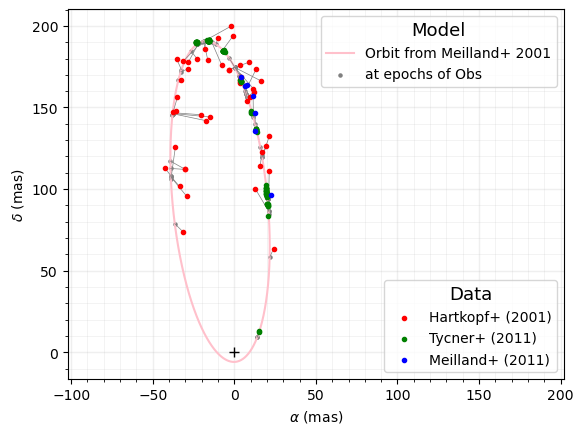

In [18]:
fig, ax = plt.subplots()
ax.grid(which="major", lw=1, alpha=0.2)
ax.grid(which="minor", lw=0.5, alpha=0.2)
ax.plot(x_mod0, y_mod0, c="pink", label="Orbit from Meilland+ 2001")

ax.axis("equal")


ax.scatter(x_mod, y_mod, color="grey", label="at epochs of Obs", marker=".",s=20)
for i in range(len(x)):
    ax.plot([x[i], x_mod[i]], [y[i], y_mod[i]], color="grey", lw=0.5)
    

data_text = ["Hartkopf+ (2001)","Tycner+ (2011)","Meilland+ (2011)"]
col=["r","g","b"]
for i in range(3):
    idx = np.where(source == i)
    ax.scatter(x[idx], y[idx], color=col[i], label=data_text[i], marker=".", zorder=10)


ax.scatter(0, 0, marker="+", color="k", s=50, lw=1, zorder=10)

p,h = ax.get_legend_handles_labels()

legend = ax.legend(p[0:2],h[0:2],title="Model", title_fontsize=13,loc=1)
ax.legend(p[2:],h[2:],title="Data", title_fontsize=13,loc=4)
ax.add_artist(legend)
ax.set_xlim(-50,150)
ax.set_xlabel("$\\alpha$ (mas)")
ax.set_ylabel("$\\delta$ (mas)")

Similarly, we plot the radial velocities with meilland et al. (2011) model.

We use the getPrimaryRadialVelocity as $\delta$ Scorpii is a SB1 spectroscopic binary.
As the orbit the very excentric we only focus on the time close to the periastron passage, betwen **T0 - T/8** and **T0 + T/8**.


In [21]:
nt = 10000
tmod = np.linspace(T0 - T/8, T0 + T/8, nt)
rv_mod = orb.getPrimaryRadialVelocity(tmod)

We can now plot the modelled orbit and compared to the data from  Miroshnichenko et al. (2001)

Text(0, 0.5, 'Radial Velocity (km/s)')

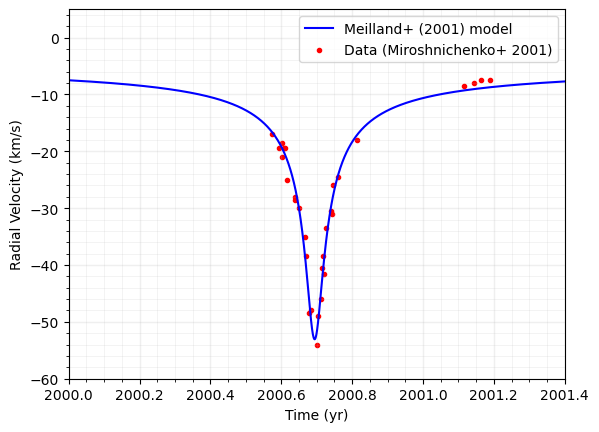

In [24]:
fi2, ax2 = plt.subplots()
ax2.grid(which="major", lw=1, alpha=0.2)
ax2.grid(which="minor", lw=0.5, alpha=0.2)

ax2.plot(Time(tmod, format="mjd").byear, rv_mod, color="b", label="Meilland+ (2001) model")
ax2.scatter(Time(mjdRv, format="mjd").byear, 
            rv, color="r", label="Data (Miroshnichenko+ 2001)", marker=".")
ax2.set_ylim(-60,5)
ax2.legend()
ax2.set_xlim(2000, 2001.4)
ax2.set_xlabel("Time (yr)")
ax2.set_ylabel("Radial Velocity (km/s)")

### Model-fitting of non-interferometric data using prior functions

Although **oimodeler** was primarly developped to model inteferometric data at the [OIFITS2](https://www.aanda.org/articles/aa/pdf/2017/01/aa26405-15.pdf) format, non-interferometric data can be added to the fit using a user define prior function.

In our case the prior function will be a weighted least-squares on the RV and separation data. As for our plots, the modelled positions and RVs at the epoch of the observations are computed using the **getSeparation** and **getPrimaryRadialVelocity** methods. 

We then compute the least-squares on both data types separately. And finally we return the sum of the two two normalized by the number of points.

In [27]:
def sepRvPrior():
    x_mod, y_mod = orb.getSeparation(mjd, mas=True)
    chi2_sep = np.sum(((x_mod - x) / err_x) ** 2 + ((y_mod - y) / err_y) ** 2)

    rv_model = orb.getPrimaryRadialVelocity(mjdRv)
    chi2_rv = np.sum(((rv - rv_model)/0.3) ** 2) # we assume 0.1km/s errors on RV
    
    chi2r =   (chi2_sep + chi2_rv) / (  mjd.size + mjdRv.size)
    return chi2r

To perform a fit, this prior function should be passed to the simulator inside the fitter.

We will use the emcee-based fitter **oimFitterEmcee** with empty interferometric data.

In [30]:
data_empty = oim.oimData() 
fit=oim.oimFitterEmcee(data_empty, morb, nwalkers=20)

We then give our prior function to the **oimSimulator** inside our fitter.

In [33]:
fit.simulator.cprior = sepRvPrior

We set the weight of the prior to be equal to the total number of data points.

In [36]:
fit.simulator.priorWeight = mjd.size + mjdRv.size 

Finally we can set the parameter space (8 free parameters), prepare the fitter and run it.


Note that we define a small parameter space aroun the know values of the orbtial elements so that convergence is faster (of the roder of 1min). You can modify the example to explore the full parameter space without any knowledge. In tha case you'll need a few more steps for convergence (try 20000).

In [39]:
orb.params["a"].set(min=80,max=100)
orb.params["T"].set(min=8,max=12)
orb.params["T0"].set(min=2000,max=2001)
orb.params["primary_f"].free=False
orb.params["secondary_f"].free=False
orb.params["O"].set(min=150,max=180)
orb.params["o"].set(min=-20,max=20)
orb.params["i"].set(min=0,max=90)    
orb.params["Ka"].set(min=20,max=25,free=True)
orb.params["V0"].set(min=-10,max=0,free=True)

fit.prepare()
fit.run(nsteps=3000,progress=True)

100%|██████████████████████████████████████████████████████████████████████████████| 3000/3000 [01:10<00:00, 42.76it/s]


{'nsteps': 3000, 'progress': True}

We plot the position of the walker as a function of the MCMC run step.

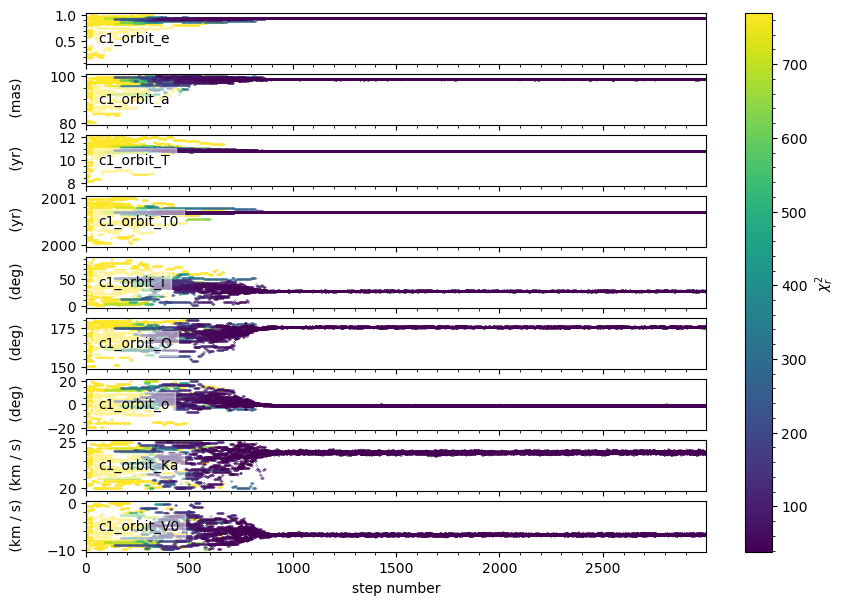

In [43]:
fig, ax = fit.walkersPlot()

We plot the corner plot.

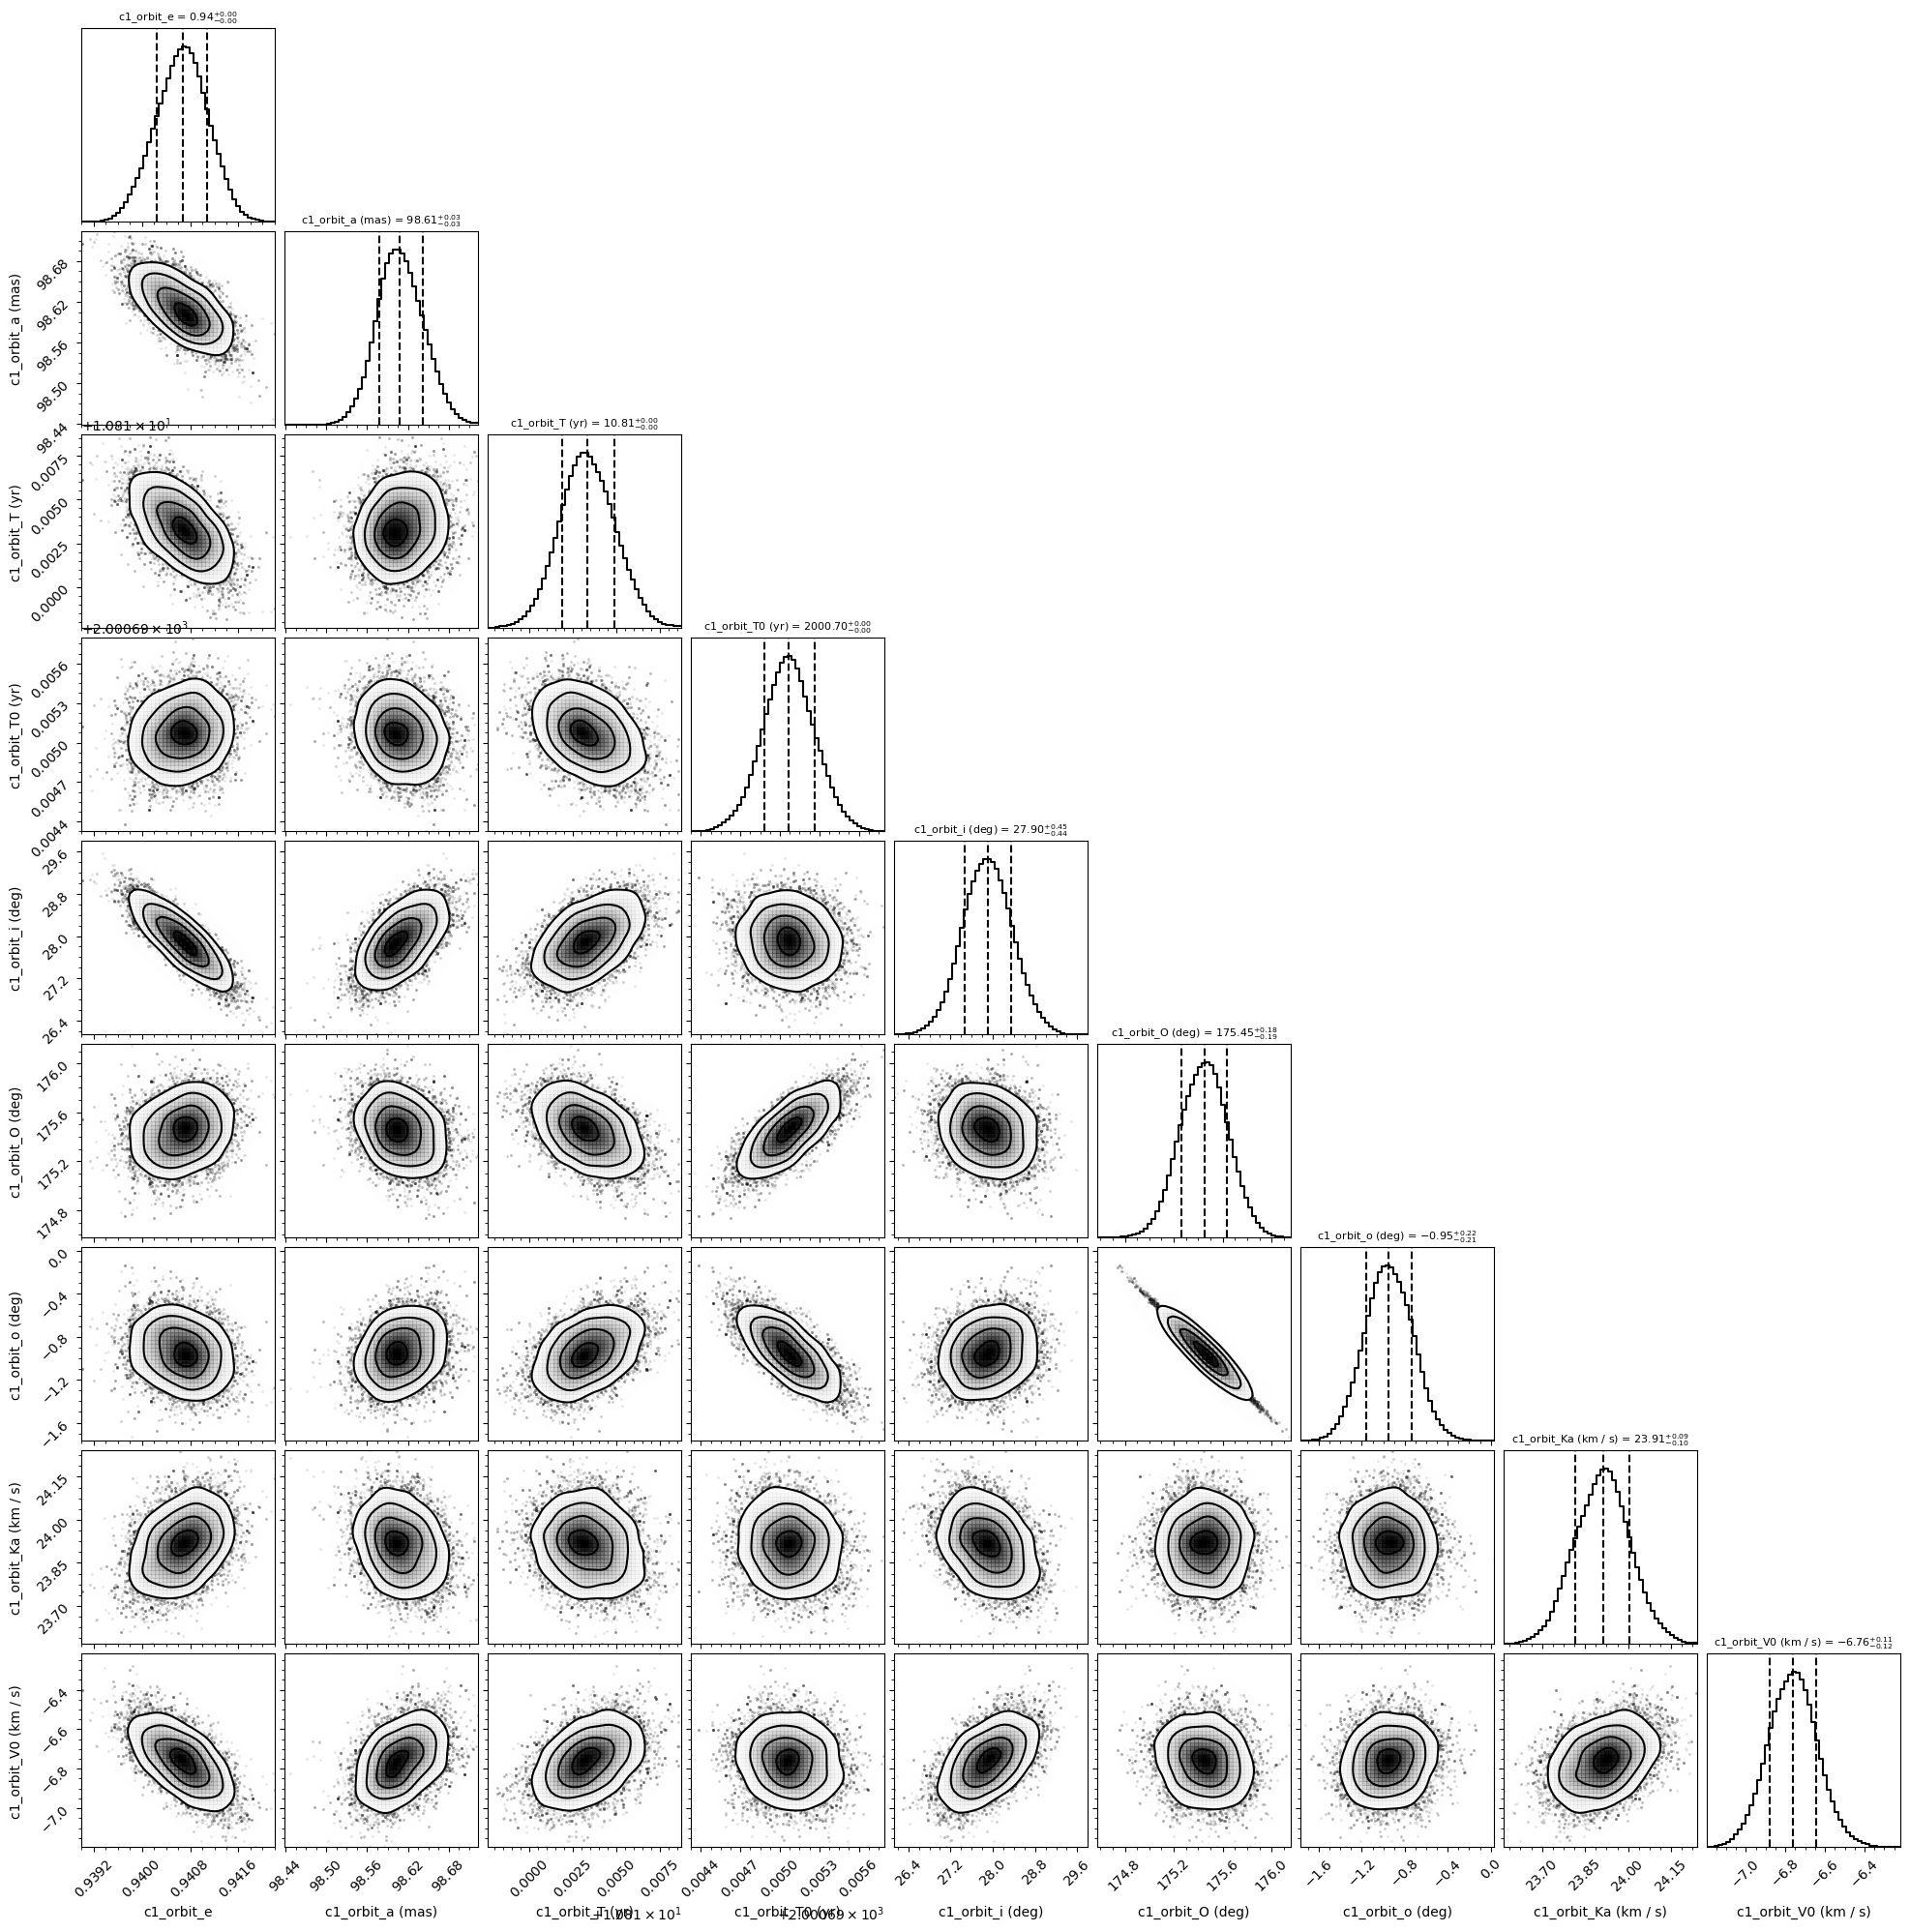

In [45]:
fig, ax = fit.cornerPlot(discard=2000)

And finally, we can get the best-fit parameter values and a posterior-probability based estimation of the uncertainties on the parameters.   

In [47]:
fit.printResults(discard=2000)

c1_orbit_e = 0.94064 ± 0.00042 
c1_orbit_a = 98.60895 ± 0.03230 mas
c1_orbit_T = 10.81322 ± 0.00151 yr
c1_orbit_T0 = 2000.69515 ± 0.00019 yr
c1_orbit_i = 27.95816 ± 0.44338 deg
c1_orbit_O = 175.53560 ± 0.18735 deg
c1_orbit_o = -1.04626 ± 0.21236 deg
c1_orbit_Ka = 23.91807 ± 0.09322 km / s
c1_orbit_V0 = -6.76730 ± 0.11600 km / s
chi2r = 38.48964


The best-fit values of the parameters are close to those found by Meilland et al. (2001).
We can make a new version of the plots of the visual orbit and rv with our new set of parameters.

Text(0, 0.5, 'Radial Velocity (km/s)')

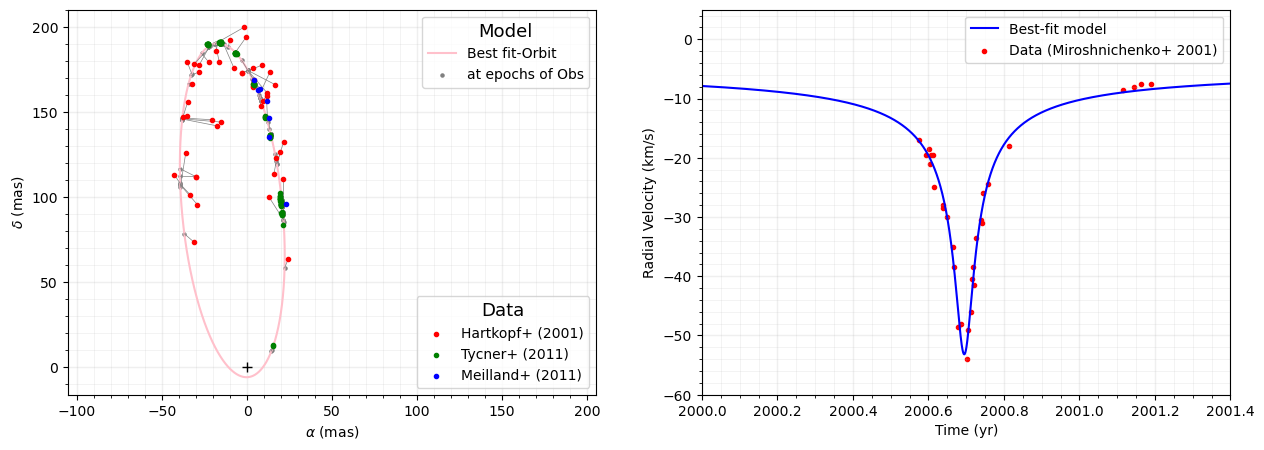

In [52]:
fig,ax = plt.subplots(1,2,figsize=(15,5))

nt = 10000
tmod = np.linspace(T0 - T/2, T0 + T/2, nt)
x_mod0, y_mod0 = orb.getSeparation(tmod, mas=True)
x_mod, y_mod = orb.getSeparation(mjd, mas=True)

ax[0].grid(which="major", lw=1, alpha=0.2)
ax[0].grid(which="minor", lw=0.5, alpha=0.2)
ax[0].plot(x_mod0, y_mod0, c="pink", label="Best fit-Orbit")
ax[0].axis("equal")
ax[0].scatter(x_mod, y_mod, color="grey", label="at epochs of Obs", marker=".",s=20)
for i in range(len(x)):
    ax[0].plot([x[i], x_mod[i]], [y[i], y_mod[i]], color="grey", lw=0.5)   
data_text = ["Hartkopf+ (2001)","Tycner+ (2011)","Meilland+ (2011)"]
col=["r","g","b"]
for i in range(3):
    idx = np.where(source == i)
    ax[0].scatter(x[idx], y[idx], color=col[i], label=data_text[i], marker=".", zorder=10)
ax[0].scatter(0, 0, marker="+", color="k", s=50, lw=1, zorder=10)
p,h = ax[0].get_legend_handles_labels()
legend = ax[0].legend(p[0:2],h[0:2],title="Model", title_fontsize=13,loc=1)
ax[0].legend(p[2:],h[2:],title="Data", title_fontsize=13,loc=4)
ax[0].add_artist(legend)
ax[0].set_xlim(-50,150)
ax[0].set_xlabel("$\\alpha$ (mas)")
ax[0].set_ylabel("$\\delta$ (mas)")


ax[1].grid(which="major", lw=1, alpha=0.2)
ax[1].grid(which="minor", lw=0.5, alpha=0.2)
nt = 10000
tmod = np.linspace(T0 - T/8, T0 + T/8, nt)
rv_mod = orb.getPrimaryRadialVelocity(tmod)

ax[1].plot(Time(tmod, format="mjd").byear, rv_mod, color="b", label="Best-fit model")
ax[1].scatter(Time(mjdRv, format="mjd").byear, 
            rv, color="r", label="Data (Miroshnichenko+ 2001)", marker=".")
ax[1].set_ylim(-60,5)
ax[1].legend()
ax[1].set_xlim(2000, 2001.4)
ax[1].set_xlabel("Time (yr)")
ax[1].set_ylabel("Radial Velocity (km/s)")

### Introducing interferometric data

Using this orbit, we will add some VLTI/AMBER measurement from Meilland et al. (2011) that was remove from the delsco_position.dat.

The dataset consist in two Medium (R$\sim1500) resdolution observations recorded on 2010-04-15.

In [55]:
data_dir = path /"data"/"RealData"/"AMBER"/"delSco"
fname = list(data_dir.glob("*.fits"))

data = oim.oimData(fname)

data.info()

════════════════════════════════════════════════════════════════════════════════
file 0: DelSco_K_2010-04-15T07h12_MR.fits
────────────────────────────────────────────────────────────────────────────────
4)	 OI_VIS  :	 (nB,nλ) = (3, 482)  	 dataTypes = ['VISPHI']           	 insname = AMBER
5)	 OI_VIS2 :	 (nB,nλ) = (3, 482)  	 dataTypes = ['VIS2DATA']         	 insname = AMBER
6)	 OI_T3   :	 (nB,nλ) = (1, 482)  	 dataTypes = ['T3PHI']            	 insname = AMBER
════════════════════════════════════════════════════════════════════════════════
file 1: DelSco_K_2010-04-15T07h55_MR.fits
────────────────────────────────────────────────────────────────────────────────
4)	 OI_VIS  :	 (nB,nλ) = (3, 482)  	 dataTypes = ['VISPHI']           	 insname = AMBER
5)	 OI_VIS2 :	 (nB,nλ) = (3, 482)  	 dataTypes = ['VIS2DATA']         	 insname = AMBER
6)	 OI_T3   :	 (nB,nλ) = (1, 482)  	 dataTypes = ['T3PHI']            	 insname = AMBER
════════════════════════════════════════════════════════════════

As the modelling of the circumstellar disk using the bright Br\$gamma$ emission line is out of the scope of our orbital modelling, we will bin the data to a lower spectral resolution of 60, which is sufficient to detect binary oscillation in the visibility and phase signals.

In [58]:
filt = oim.oimWavelengthBinningFilter(bin=25)
data.setFilter(filt)

Let's have a look at the data itself by plotting the visibility, closure phase and the (u,v) plan.

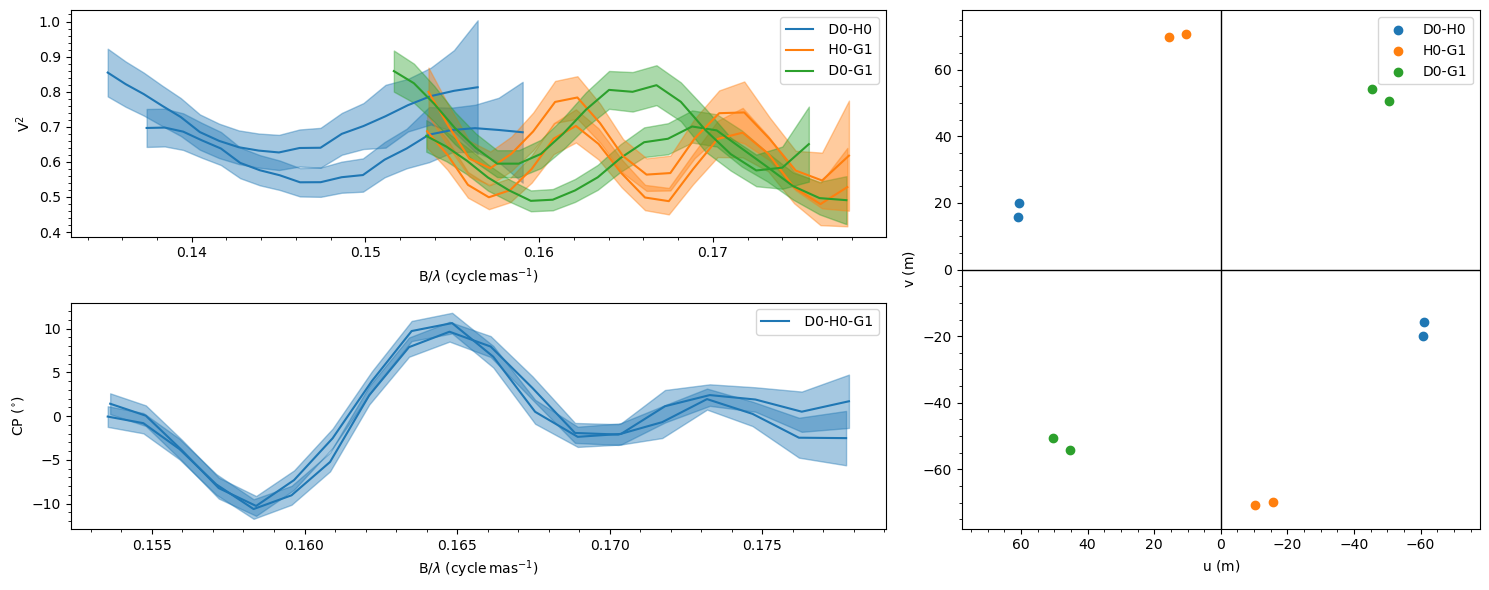

In [61]:
figData = plt.figure(figsize=(15,6))#constrained_layout=True)
gs = figData.add_gridspec(2,5)
ax_uv = figData.add_subplot(gs[:, -2:],projection='oimAxes')
ax_v2 =  figData.add_subplot(gs[0, :-2],projection='oimAxes')
ax_cp =  figData.add_subplot(gs[1, :-2],projection='oimAxes')
data.uvplot(color="byBaseline",axe=ax_uv)
data.plot("SPAFREQ","VIS2DATA",color="byBaseline",xunit="cycle/mas",axe=ax_v2,legend=True,errorbar=True)
data.plot("SPAFREQ","T3PHI",color="byBaseline",xunit="cycle/mas",axe=ax_cp,legend=True,errorbar=True)
figData.tight_layout()

We will first perform a simple two-components fit without using the **oimBinaryOrbit** component. To take into account the partial resolution of the primary, we choose to model it as a uniform disk. On the other hand, the secondary is considered unresolved and modelled as a point-like source.

In [64]:
ud = oim.oimUD()
pt = oim.oimPt()
model = oim.oimModel(ud,pt)
model.normalizeFlux()
ud.params["d"].set(min=0,max=5)
pt.params["x"].set(min=-150,max=150,free=True)
pt.params["y"].set(min=-150,max=150,free=True)
ud.params["f"].set(min=0.9,max=1)

We perform a basic MCMC run on the secondary position and the relative flux of the primary. 

In [69]:
fit2 = oim.oimFitterEmcee(data,model,nwalkers=20,dataTypes=["VIS2DATA","T3PHI"])
fit2.prepare()
fit2.run(nsteps=10000,progress=True)

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [01:30<00:00, 110.88it/s]


{'nsteps': 10000, 'progress': True}

We plot the position of the walkers.

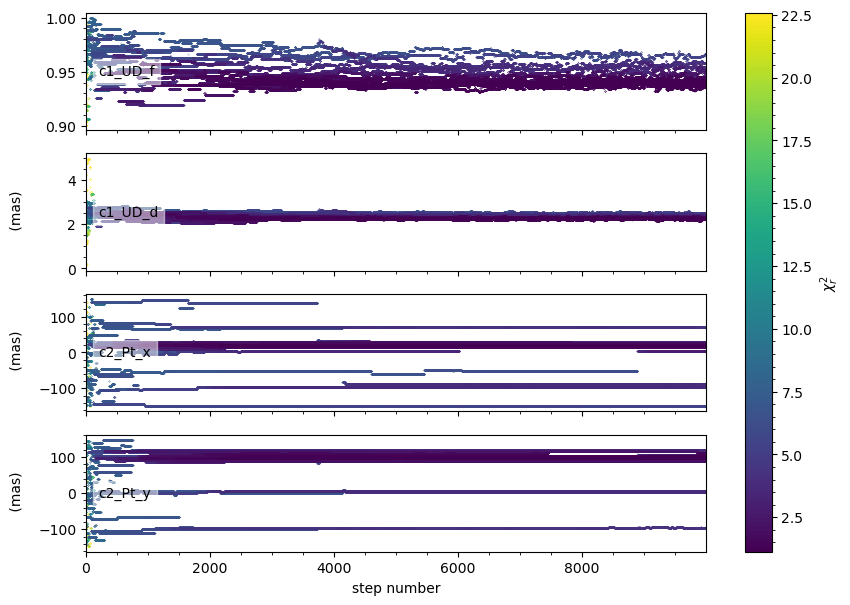

In [71]:
figWalker, axWalker = fit2.walkersPlot()

We see that the walkers hardly converge to a single position. Mulitple local minimas of $\chi^2$ is a common feature when fitting binary observations.

We can evidence these mimina and search of the global one more efficiently using grid search. 

But first let's retrieve some results from thsi fit to define our grid parameter space. 

To compute the parameters and uncertainties we discard the first 8000 steps and points with more than 3 times the minimum of the $\chi^2$ to avoid contamination by the less likely local minimas.

In [74]:
fit2.printResults(discard=8000,chi2limfact=3)

c1_UD_f = 0.94039 ± 0.00326 
c1_UD_d = 2.26922 ± 0.04158 mas
c2_Pt_x = 19.91810 ± 2.71664 mas
c2_Pt_y = 103.27306 ± 3.31355 mas
chi2r = 1.12925


The primary relative flux **f** and diameter **d** are well constrained. We will perform a 2D grid search on the companion positions **x** and **y**.
We define the grid range as a few times the MCMC uncertainties. 

Although the uncertainties are larger on **y**, we decide to have the same range on **x** and **y** for plotting reason.

We also decide to store the position (**x_fit**, **y_fit**) and uncertainties (**x_fit_err**, **y_fit_err**) to plot them later.

In [78]:
x_fit, y_fit = pt.params["x"].value,pt.params["y"].value
x_fit_err, y_fit_err = pt.params["x"].error,pt.params["y"].error

xmin = pt.params["x"].value-25
xmax = pt.params["x"].value+25
ymin = pt.params["y"].value-25
ymax = pt.params["y"].value+25
print(xmin,ymin,xmax,ymax)

-5.081896443470434 78.27305983787254 44.918103556529566 128.27305983787255


We create and run the grid using the **oimFitterRegularGrid** fitter.

In [81]:
grid = oim.oimFitterRegularGrid(data,model,dataTypes=["VIS2DATA","T3PHI"])
grid.prepare(params=[pt.params["x"],pt.params["y"]],min=[xmin,ymin],max=[xmax,ymax],steps=[0.2,0.2])
grid.run()

100%|██████████████████████████████████████████████████████████████████████████| 63001/63001 [00:40<00:00, 1563.13it/s]


{}

We plot the grid wih the option to show a contour at twice the minimum $\chi^2_r$ using the **plotContour=True** option.

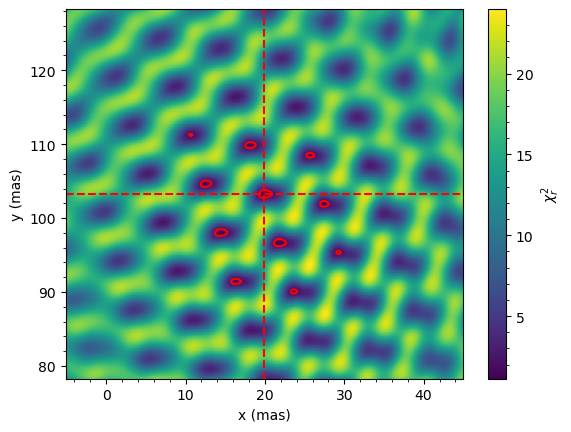

In [83]:
figGrid,axGrid = grid.plotMap(plotContour=True,plotMin=False,plotMinLines=True)

Multiple local minima, shown in red, have a $\chi^2$ low enough to be considered as possible position of the companion.

They are located around the  global minimum (marked by the crossing red lines).

Let's overplot this distribution over $\delta$ Sco orbit.

(80.0, 120.0)

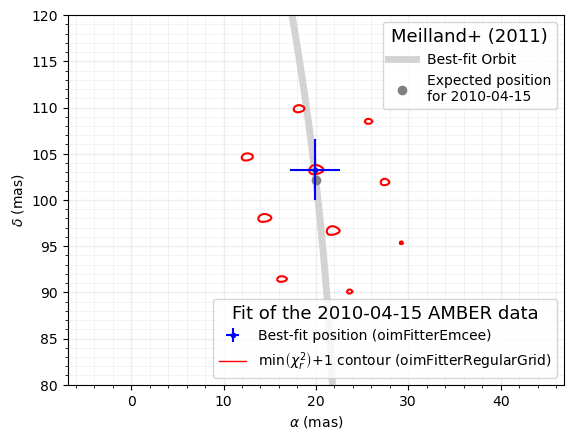

In [86]:
fig,ax = plt.subplots()
ax.grid(which="major", lw=1, alpha=0.2)
ax.grid(which="minor", lw=0.5, alpha=0.2)


MJD = data.data[0]["OI_VIS2"].data["MJD"][0]
dateText=Time(MJD,format="mjd").iso.split()[0]

#plotting the orbit from Meiulland+ 2001
nt = 10000
tmod = np.linspace(T0 - T/2, T0 + T/2, nt)
x_mod0, y_mod0 = orb.getSeparation(tmod, mas=True)
ax.plot(x_mod0,y_mod0,color="lightgrey",label="Best-fit Orbit",lw=5)
ax.axis('equal')



#overplotting the Chi2r_min+1 contour from the grid exploration
im = grid.chi2rMap
X,Y = np.meshgrid(grid.grid[0],grid.grid[1])
ax.contour(X,Y,np.transpose(im),levels=[im.min()+1],colors="r")

# Plottinf the expected position at AMBER data MJD according to Meilland+ 2001 orbit
x0,y0 = orb.getSeparation(MJD,mas=True)
ax.scatter(x0,y0,color="grey",marker="o",
           label=f"Expected position\nfor {dateText}",zorder=10)

#plotting the best-fit position from the mcmc run on the AMBER data
ax.errorbar(x_fit,y_fit,xerr=x_fit_err,yerr=y_fit_err,color="b",marker=".",
            ls="",label="Best-fit position (oimFitterEmcee)",zorder=10)

p,h = ax.get_legend_handles_labels()
p.append(Line2D([0], [0], color='r', lw=1, label='Line'))
h.append("min$\\left(\\chi^2_r\\right)$+1 contour (oimFitterRegularGrid)")


legend = ax.legend(p[0:2],h[0:2],title="Meilland+ (2011)", 
                   title_fontsize=13,loc=1)
ax.legend(p[2:],h[2:],title=f"Fit of the {dateText} AMBER data", 
          title_fontsize=13,loc=4)
ax.add_artist(legend)

ax.set_xlabel("$\\alpha$ (mas)")
ax.set_ylabel("$\\delta$ (mas)")

ax.set_xlim(0,40)
ax.set_ylim(80,120)

What we see here is that the global minimum is close to the expected position, but still slightly shifted of two times more than the $min(\chi^2_r)+1$ evaluation of the uncertainties.


### Simulatenous model-fitting of separation, RVs and interferometric data

To perform the global fit of all data, we need to modify the **oimBinaryOrbit** component to take into account the partial resolution of the primary.

We replace the standar point-like source for the primary by a uniform disk.

In [90]:
orb.primary=oim.oimUD(d=2.3,f=0.94)

Using the **normalizeFlux=True** option we normalize the total flux of the two components in  the **oimBinaryOrbit**.

In [93]:
orb.normalizeFlux = True

Finally we modify the parameter space as the primary diameter and fluxes will now become free parameters.

In [96]:
orb.primary.params["d"].set(min=0,max=5)
orb.primary.params["d"].set(min=0,max=5)
orb.primary.params["f"].set(min=0.9,max=1)

Using the **getFreeParameters** we can check that the parameter space for our 11 free parameters is properly set.

In [99]:
morb.getFreeParameters()

{'c1_orbit_e': oimParam at 0x1f7759ecb30 : e=0.9406408605666062 ± 0.0004192587035263262  range=[0,1] free=True ,
 'c1_orbit_a': oimParam at 0x1f7750aa150 : a=98.60894666483397 ± 0.03230099859636937 mas range=[80,100] free=True ,
 'c1_orbit_T': oimParam at 0x1f7750ab620 : T=10.813222561064045 ± 0.0015099884786913265 yr range=[8,12] free=True ,
 'c1_orbit_T0': oimParam at 0x1f7750a9fd0 : T0=2000.6951548109014 ± 0.00018968756853610103 yr range=[2000,2001] free=True ,
 'c1_orbit_i': oimParam at 0x1f7750aaf60 : i=27.958158787653968 ± 0.4433827815696425 deg range=[0,90] free=True ,
 'c1_orbit_O': oimParam at 0x1f7750a8110 : O=175.5356044636005 ± 0.187349754121513 deg range=[150,180] free=True ,
 'c1_orbit_o': oimParam at 0x1f7750a9fa0 : o=-1.0462633823693268 ± 0.21235618166948095 deg range=[-20,20] free=True ,
 'c1_orbit_Ka': oimParam at 0x1f7750a8530 : Ka=23.91807499007014 ± 0.093222399587086 km / s range=[20,25] free=True ,
 'c1_orbit_V0': oimParam at 0x1f77e6181a0 : V0=-6.767300824689682 

We set up an MCMC fitter on our **AMBER** data, fitting only **VIS2DATA** and **T3PHI**.

We set the simulator prior function too the one defined before (least-square on the separation and radial velocities).

Finally, we set the **priorWeight** to 1 (the default value). When modelling interferometric data simultaneously with a prior function, this weight is relative: setting it to unity implies that the contribution of the prior and the interferometric $\chi^2$ have the same strength.

This weight may need to be adjusted. If it is set too high, the fit will be dominated by the external prior, whereas if it is too low, the solution will be driven almost entirely by the interferometric data.

In [102]:
fit3=oim.oimFitterEmcee(data, morb, nwalkers=30,dataTypes=["VIS2DATA","T3PHI"])
fit3.simulator.cprior = sepRvPrior 
fit3.priorWeight = 1
fit3.prepare()

{}

We run the simulator for 3000 steps.

In [105]:
fit3.run(nsteps=3000,progress=True)

100%|██████████████████████████████████████████████████████████████████████████████| 3000/3000 [02:36<00:00, 19.23it/s]


{'nsteps': 3000, 'progress': True}

We plot the walker to check convergence.

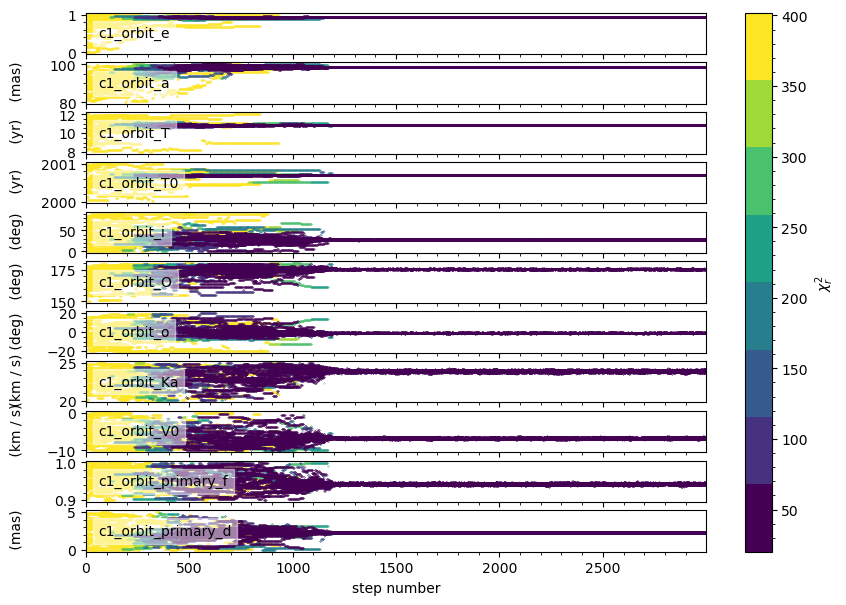

In [107]:
figWalker, axWalker = fit3.walkersPlot(ncolors=8)

We plot the data/model comparison on the interferometric data.

(-20.0, 20.0)

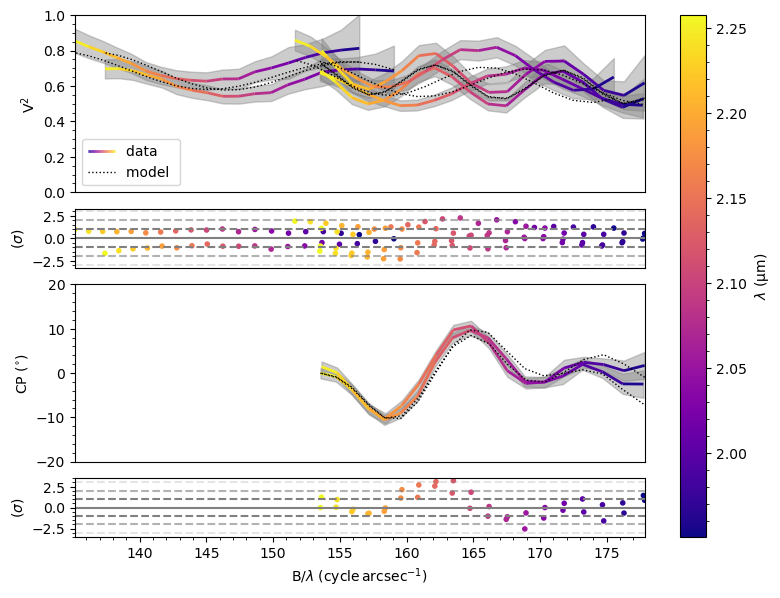

In [110]:
figwFit, axFit = fit3.simulator.plotWithResiduals(["VIS2DATA","T3PHI"],xunit="cycle/arcsec")
axFit[2].set_ylim(-20,20)

And finally, we print the result.

In [113]:
fit3.printResults(chi2limfact=5,discard=2000)

c1_orbit_e = 0.94073 ± 0.00045 
c1_orbit_a = 98.54478 ± 0.03711 mas
c1_orbit_T = 10.82773 ± 0.00135 yr
c1_orbit_T0 = 2000.69513 ± 0.00020 yr
c1_orbit_i = 27.80424 ± 0.46738 deg
c1_orbit_O = 175.52537 ± 0.20642 deg
c1_orbit_o = -1.01511 ± 0.23537 deg
c1_orbit_Ka = 23.86519 ± 0.10009 km / s
c1_orbit_V0 = -6.80000 ± 0.13444 km / s
c1_orbit_primary_f = 0.94246 ± 0.00160 
c1_orbit_primary_d = 2.29665 ± 0.02477 mas
chi2r = 20.09794


Let's plot the comparison with the orbit.

(102.0, 104.0)

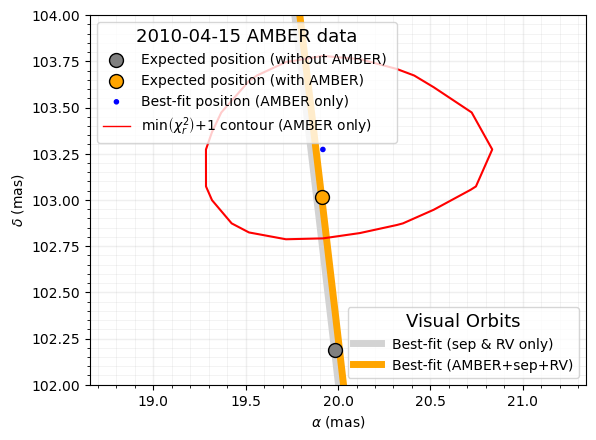

In [137]:
fig,ax = plt.subplots()
ax.grid(which="major", lw=1, alpha=0.2)
ax.grid(which="minor", lw=0.5, alpha=0.2)
ax.axis('equal')

MJD = data.data[0]["OI_VIS2"].data["MJD"][0]
dateText=Time(MJD,format="mjd").iso.split()[0]

nt = 10000
tmod = np.linspace(T0 - T/2, T0 + T/2, nt)

#plotting the orbit from sep & rv DATA only
fit.getResults(discard=2000)
x_mod0, y_mod0 = orb.getSeparation(tmod, mas=True)
ax.plot(x_mod0,y_mod0,color="lightgrey",label="Best-fit (sep & RV only)",lw=5)
x0,y0 = orb.getSeparation(MJD,mas=True)

#plotting the orbit from AMBER + other DATA
fit3.getResults(chi2limfact=5,discard=2000)

x_mod0, y_mod0 = orb.getSeparation(tmod, mas=True)
x0b,y0b = orb.getSeparation(MJD,mas=True)
ax.plot(x_mod0,y_mod0,color="orange",label="Best-fit (AMBER+sep+RV)",lw=5)


#overplotting the Chi2r_min+1 contour from the grid exploration
im = grid.chi2rMap
X,Y = np.meshgrid(grid.grid[0],grid.grid[1])
ax.contour(X,Y,np.transpose(im),levels=[im.min()+1],colors="r")

# Plottinf the expected position at AMBER data MJD according to Meilland+ 2001 orbit

ax.scatter(x0,y0,color="grey",marker="o",s=100,edgecolor="k",
           label=f"Expected position (without AMBER) ",zorder=10)

ax.scatter(x0b,y0b,color="orange",marker="o",s=100,edgecolor="k",
           label=f"Expected position (with AMBER)",zorder=10)

ax.scatter(x_fit,y_fit,color="b",marker=".",
            ls="",label="Best-fit position (AMBER only)",zorder=10)


p,h = ax.get_legend_handles_labels()
p.append(Line2D([0], [0], color='r', lw=1, label='Line'))
h.append("min$\\left(\\chi^2_r\\right)$+1 contour (AMBER only)")


legend = ax.legend(p[0:2],h[0:2],title="Visual Orbits", 
                   title_fontsize=13,loc=4)
ax.legend(p[2:],h[2:],title=f"{dateText} AMBER data", 
          title_fontsize=13,loc=2)
ax.add_artist(legend)

ax.set_xlabel("$\\alpha$ (mas)")
ax.set_ylabel("$\\delta$ (mas)")

ax.set_xlim(19,21)
ax.set_ylim(102,104)


Although the best-fit parameters did not change significantly, the agreement between the 2010-04-15 AMBER data and the modelled orbit is now excellent.